# <center>Metody Numeryczne<br></center>

## Laboratorium 3: Błędy Numeryczne

**Instrukcja:**

Na zajęciach należy wykonać poniższe polecenia.

Funkcje, o których mowa w zadaniach, należy zaimplementować w pliku `main.py`.

Końcowe sprawozdanie powinno zawierać kod źródłowy z komentarzami oraz odpowiedzi na pytania zawarte w treści zadań.

<br>

**Materiały przygotowujące:**
- Standard IEEE 754 [PL](https://pl.wikipedia.org/wiki/IEEE_754) [EN](https://en.wikipedia.org/wiki/IEEE_754)
- Liczba zmiennoprzecinkowa [PL](https://pl.wikipedia.org/wiki/Liczba_zmiennoprzecinkowa) [EN](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
- Arytmetyka zmiennoprzecinkowa [Python](https://docs.python.org/3/tutorial/floatingpoint.html)
- IPython - wbudowane metody magiczne (np. `%%time`, `%load`) ([link](https://ipython.readthedocs.io/en/stable/interactive/magics.html))

<br>

**Uwagi wstępne:**

- Do wykonania zadania niezbędne jest posiadanie następujących bibliotek: *numpy*, *scipy*, *matplotlib*, *memory_profiler*, *setuptools*
- Biblioteka [*memory_profiler*](https://pypi.org/project/memory-profiler/) do poprawnego działania wymaga zainstalowania modułu *setuptools*.

In [46]:
import main
import math
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt

%load_ext memory_profiler

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


**Profilowanie kodu:**

Profilowanie kodu to proces analizowania działania programu w celu zidentyfikowania, które jego części zużywają najwięcej zasobów, takich jak czas czy pamięć. Podczas tych zajęć do profilowania wykorzystamy moduły *timeit* i *memit*, natomiast zainteresowanych tematem zachęcamy do zapoznania się z *scalene* i *time.perf_counter*.

- [timeit](https://docs.python.org/3/library/timeit.html) - profilowanie czasu wykonywania kodu 
- [memit](https://pypi.org/project/memory-profiler/) - profilowanie pamięci zużywanej przez kod

In [47]:
def func(size):
    a = np.random.random((size, size))
    b = np.random.random((size, size))
    c = a + b
    return c


for size in [100, 1000, 10000]:
    print("SIZE: ", size)
    print("Timing: ")
    saved_timing = %timeit -r 3 -n 3 -o func(size)
    print(f"Avg. time: {saved_timing.average:.6f}") # średni czas próby
    print(f"Std. dev.: {saved_timing.stdev:.6f}")   # odchylenie standardowe
    print("Memory usage: ")
    %memit func(size)
    print("\n")

SIZE:  100
Timing: 
128 μs ± 29.1 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)
Avg. time: 0.000128
Std. dev.: 0.000029
Memory usage: 
peak memory: 137.44 MiB, increment: 0.08 MiB


SIZE:  1000
Timing: 
11.9 ms ± 130 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)
Avg. time: 0.011922
Std. dev.: 0.000130
Memory usage: 
peak memory: 145.08 MiB, increment: 0.00 MiB


SIZE:  10000
Timing: 
1.27 s ± 20.3 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)
Avg. time: 1.267939
Std. dev.: 0.020300
Memory usage: 
peak memory: 2239.06 MiB, increment: 2102.33 MiB




### Zadanie 1.  
Zaimplementuj funkcje obliczające błąd względny i bezwzględny (*relative_error* i *absolute_error*). Funkcje przyjmują 2 argumenty: wartość dokładną oraz wartość przybliżoną, zwracając wartość błędu. Implementacja powinna obsługiwać zarówno wartości skalarne, listy oraz wektory i macierze typu np.array z zachowaniem zasad [broadcastingu](https://numpy.org/doc/stable/user/basics.broadcasting.html).

**Wskazówka:** Wykorzystuj funkcje *relative_error* i *absolute_error* w dalszej części laboratorium do analizy błędów.

In [48]:
def absolute_error(
    v: int | float | list | np.ndarray, v_approx: int | float | list | np.ndarray
) -> int | float | np.ndarray:
        
        try:
            v=np.asarray(v)
            v_approx=np.asarray(v_approx)
            err=np.abs(v-v_approx)
            return err
        except(ValueError,TypeError):
            return np.nan


def relative_error(
    v: int | float | list | np.ndarray, v_approx: int | float | list | np.ndarray
) -> int | float | np.ndarray:

        try:
            v=np.asarray(v)
            v_approx=np.asarray(v_approx)
            err=np.abs(v-v_approx)/v
            return err
        
        except(ValueError,TypeError):
            return np.nan


Zadanie poprawiono i kod jest taki sam jak na tablicy podczas lekcji. Użyto try i except, które przydało się w każdej następnej funkcji.

### Zadanie 2.  
Zaimplementuj funkcje *p_diff*, która przyjmuje jako parametry wartości całkowite $n$ i rzeczywiste $c$ oraz zwraca różnicę (co do wartości bezwzględnej)   dwóch wyrażeń $P_1$ oraz $P_2$:  
  
a) $P_1 = b - b + c $  
b) $P_2 = b + c - b $  
  
gdzie $b = 2^n$

Analizując różnicę w otrzymanych wynikach zastosuj wartości:  
- $n \in \{1,2,3... 50\}$
- $c \in \{0.1, 0.125, 0.25, 0.33, 0.5, 0.6\}$
 
Następnie odpowiedz na pytania, swoje odpowiedzi poprzyj wykresami:

1. Jaki wynik powinniśmy otrzymać?
2. Które z liczb mają skończoną a które nieskończoną reprezentację?    
3. Dlaczego wyniki się od siebie różnią?    
4. Jaki typ błędu tutaj występuje?
5. Czy istnieje możliwość poprawy działania tych wyrażeń, jeżeli tak to w jaki sposób?  


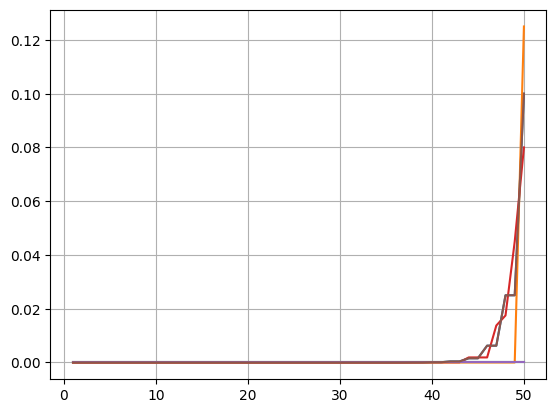

In [49]:
def p_diff(n: int, c: int | float) -> float:
    try:
        if not isinstance(n, int):
            return np.nan
        
        c_float = np.float64(c)
        b = np.float64(2**n)
        P1 = b - b + c_float
        P2 = b + c_float - b
        return abs(P1 - P2)
    
    except (TypeError, ValueError):
        return np.nan
c_zbior = [0.1,0.125,0.25,0.33,0.5,0.6]
n_zbior = range(1,51)
err=0
for c in c_zbior:
    wyliczony_ERR = [p_diff(n, c) for n in n_zbior]
    plt.plot(n_zbior, wyliczony_ERR)
plt.grid()
plt.show()

1. Powinniśmy otrzymać te same wyniki.
2. Liczby wymierne, których rozwinięcie dziesiętne jest skończone mają skończoną reprezentacje np. 1/4=0.25, ale taka 1/3 ma nieskonczoną reprezetnację
3. dla dużych n, końcówki się przycinają i tworzą się zaokraglenia.
4. błąd zaokrąglenia
5. stosować typy o większej precyzji, zapisać że P = c


### Zadanie 3.
Wartości funkcji $\mathrm{e}^{x}$ można obliczyć w przybliżeniu z szeregu Taylora w następujący sposób:  
  
$\mathrm{e}^{x} \approx \sum\limits_{i=0}^{N}{\cfrac{1}{i!}x^{i}}$ 
  
na podstawie przedstawionych informacji zaimplementuj funkcje *exponential* która oblicza $\mathrm{e}^{x}$ z zadaną dokładnością $N$. Porównaj działanie utworzonej funkcji z [numpy.exp](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.exp.html). Odpowiedz na pytania:  

1. Jaki typ błędu obrazuje omawiany przykład?
2. Dokonaj analizy błędów bezwzględnych i względnych w zależności od wartości $n$.

In [50]:
def exponential(x: int | float, n: int) -> float:
    try:
        x=float(x)
        if n<0:
            return np.nan
        exp_approx=0
        for i in range(0,n):
            exp_approx+=(x**i)/math.factorial(i)
        return exp_approx
    
    except (TypeError, ValueError):
        return np.nan


In [51]:
print(np.exp(2))
exponential(2,8)

7.38905609893065


7.3809523809523805

In [52]:
X=2
max_n = 20

for n in range(1, max_n + 1):

    V_True = np.exp(X)
    V_zmierzone = exponential(X, n)

    absERR = absolute_error(V_True, V_zmierzone)
    relERR = relative_error(V_True, V_zmierzone)
    
    print(f"n = {n}; Błąd bezwzględny: {absERR:.15f}; Błąd względny: {relERR:.15f}")

n = 1; Błąd bezwzględny: 6.389056098930650; Błąd względny: 0.864664716763387
n = 2; Błąd bezwzględny: 4.389056098930650; Błąd względny: 0.593994150290162
n = 3; Błąd bezwzględny: 2.389056098930650; Błąd względny: 0.323323583816937
n = 4; Błąd bezwzględny: 1.055722765597317; Błąd względny: 0.142876539501453
n = 5; Błąd bezwzględny: 0.389056098930650; Błąd względny: 0.052653017343711
n = 6; Błąd bezwzględny: 0.122389432263984; Błąd względny: 0.016563608480614
n = 7; Błąd bezwzględny: 0.033500543375095; Błąd względny: 0.004533805526249
n = 8; Błąd bezwzględny: 0.008103717978270; Błąd względny: 0.001096718967859
n = 9; Błąd bezwzględny: 0.001754511629064; Błąd względny: 0.000237447328261
n = 10; Błąd bezwzględny: 0.000343576884796; Błąd względny: 0.000046498075017
n = 11; Błąd bezwzględny: 0.000061389935943; Błąd względny: 0.000008308224369
n = 12; Błąd bezwzględny: 0.000010083217969; Błąd względny: 0.000001364615160
n = 13; Błąd bezwzględny: 0.000001532098307; Błąd względny: 0.00000020734

Funkcja np.exp od razu liczy z wysoką dokładnością, a exponential dopiero dla wyższych N osiąga lepsze przybliżenie.

### Zadanie 4.  
Zaimplementuj 2 funkcje $coskx1$ i $coskx2$, realizujące rekurencyjnie przybliżanie wartości $cos(kx)$ w następujący sposób:

- Metoda 1:         
$cos(m+1)x = 2cosx \cdot cos(mx) - cos(m-1)x$
- Metoda 2:     
$cos(mx) = cosx \cdot cos(m-1)x - sinx \cdot sin(m-1)x$       
$sin(mx) = sinx \cdot cos(m-1)x + cosx \cdot sin(m-1)x$

Następnie przeanalizuj otrzymane rezultaty dla różnych $k$.

**Wskazówka** Do wyliczenia wartości $sin(x)$, $cos(x)$ (dla $k=1$) można użyć funkcji biblioteki numpy. 
Pozostałe wartości dla $k>1$ należy wyznaczyć rekurencyjnie.

In [53]:
def coskx1(k: int, x: int | float) -> float:
    try:
        if not isinstance(k, int) or k<0:
            return np.nan
        if k==0:
            return 1
        elif k==1:
            return np.cos(x)
        else:
            return 2*np.cos(x)*coskx1((k-1),x) - coskx1((k-2),x)
    except (TypeError, ValueError):
        return np.nan

def coskx2(k: int, x: int | float) -> tuple[float, float]:
    try:
        if not isinstance(k, int) or k<0:
            return np.nan
        k=abs(k)
        if k==0:
            return(1,0)
        elif k==1:
            return (np.cos(x),np.sin(x))
        else:
            (cos, sin) = coskx2(k-1, x) #tworzę funkcję coskx2, która zwróci krotkę (cos,sin)
            kcos = np.cos(x) * cos - np.sin(x) * sin #koncwoy wynik, który się rekurencyjnie oblicza
            ksin = np.sin(x) * cos + np.cos(x) * sin
            return (kcos, ksin)
    except (TypeError, ValueError):
        return np.nan

### Zadanie 5.
Używając funkcji `%timeit` oraz `%memit` zbadaj czas działania oraz zużycie pamięci funkcji *exponential* z Zadania 3. w zależności od różnych wartości $N$.     
Sporządź wykresy:
- czasu obliczenia danego przybliżenia liczby $e$ w zależności od $N$. 
W tym celu wykorzystaj funkcje [errorbar](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.errorbar.html) oraz zwracane przez *timeit* wartości średnie oraz ich odchylenie standardowe. 
- błędu bezwzględnego przybliżenia liczby $e$ od czasu jego wykonania.



**Wskazówka** Użyj opcji -o (output) dla *timeit* aby zapisać wynik do zmiennej. Opcje -r (runs) i -n (liczba pętli) decydują o liczbie wykonanych prób.     
Do wizualizacji wyników użyj skali logarytmicznej.

In [56]:
n_values = list(range(1, 50))
x = 1                      
true_e = np.e              


Niestety nie za bardzo mam pojęcie jak wykonać to zadanie 5.